# Notebook 01 — Análise Exploratória de Dados (EDA)

**Objetivo:** Conhecer o dataset IMDB 50K Movie Reviews antes de qualquer processamento.

Esta etapa é fundamental para entender a estrutura dos dados, identificar possíveis problemas (valores nulos, desequilíbrio de classes, etc.) e justificar as decisões tomadas nas etapas seguintes.

**Dataset:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

**Colunas esperadas:**
- `review`: texto da avaliação do usuário
- `sentiment`: rótulo da classe (`positive` ou `negative`)

In [1]:
# Montar o Google Drive para acessar os arquivos do projeto
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Importações

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

## 2. Carregamento e Inspeção Inicial

O primeiro passo é carregar o dataset e verificar sua estrutura básica: número de linhas, colunas e primeiras amostras.

In [3]:
# Carregar o dataset bruto a partir do Google Drive
df = pd.read_csv('/content/drive/MyDrive/tcc-sentiment-analysis/data/IMDB Dataset.csv')

print("Shape:", df.shape)           # Esperado: (50000, 2)
print("\nColunas:", df.columns.tolist())
print("\nPrimeiras linhas:")
df.head()

Shape: (50000, 2)

Colunas: ['review', 'sentiment']

Primeiras linhas:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 3. Qualidade dos Dados

Verificamos a presença de valores nulos e a distribuição das classes (`positive` / `negative`).

Um dataset balanceado (mesmo número de exemplos por classe) é importante para evitar viés nos modelos treinados.

In [4]:
# Verificar valores nulos e tipos de dados
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nTipos de dados:")
print(df.dtypes)

# Distribuição das classes — esperado: 25.000 positive e 25.000 negative
print("\nDistribuição de classes:")
print(df['sentiment'].value_counts())

Valores nulos por coluna:
review       0
sentiment    0
dtype: int64

Tipos de dados:
review       object
sentiment    object
dtype: object

Distribuição de classes:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## 4. Visualização da Distribuição das Classes

O gráfico abaixo confirma que o dataset é **perfeitamente balanceado**, com exatamente 25.000 avaliações positivas e 25.000 negativas. Isso elimina a necessidade de técnicas de balanceamento (como oversampling ou undersampling) e permite usar a acurácia como métrica complementar ao F1-Score.

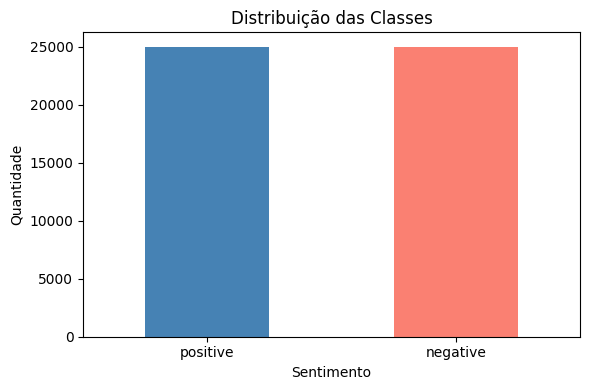

In [5]:
# Gráfico de distribuição das classes
plt.figure(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribuição das Classes')
plt.xlabel('Sentimento')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()

# Salvar gráfico para uso no TCC
plt.savefig('/content/drive/MyDrive/tcc-sentiment-analysis/results/distribuicao_classes.png', dpi=150)
plt.show()

## 5. Análise do Comprimento dos Reviews

Analisamos a distribuição do número de palavras por review. Essa informação é útil para:
- Entender a complexidade do texto
- Identificar reviews muito curtos (potencialmente menos informativos) ou muito longos
- Justificar a necessidade de remoção de stopwords (palavras frequentes que pouco contribuem para o sentido)

Estatísticas de comprimento dos reviews (em palavras):
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


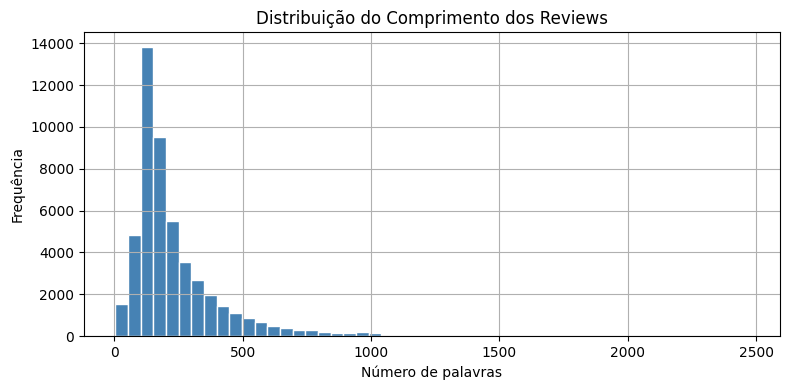

In [6]:
# Calcular o número de palavras por review
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print("Estatísticas de comprimento dos reviews (em palavras):")
print(df['review_length'].describe())

# Histograma do comprimento dos reviews
plt.figure(figsize=(8, 4))
df['review_length'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribuição do Comprimento dos Reviews')
plt.xlabel('Número de palavras')
plt.ylabel('Frequência')
plt.tight_layout()

# Salvar gráfico para uso no TCC
plt.savefig('/content/drive/MyDrive/tcc-sentiment-analysis/results/comprimento_reviews.png', dpi=150)
plt.show()

## 6. Identificação de Tags HTML

Os reviews do IMDB contêm tags HTML (como `<br />`) que foram preservadas durante a extração dos dados. Esse exemplo ilustra a necessidade da etapa de pré-processamento: sem limpeza, essas tags seriam tratadas como "palavras" pelos vetorizadores, adicionando ruído ao modelo.

In [7]:
# Exibir um review bruto para evidenciar a presença de tags HTML
# Essa evidência justifica a etapa de limpeza no notebook 02
print("Exemplo de review bruto (primeiros 500 caracteres):")
print(df['review'][0][:500])

Exemplo de review bruto (primeiros 500 caracteres):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ


---
## Conclusões da EDA

- O dataset contém **50.000 reviews** com **2 colunas** (`review` e `sentiment`)
- **Sem valores nulos** — não há necessidade de imputação
- Dataset **perfeitamente balanceado**: 25.000 positivos e 25.000 negativos
- Reviews contêm **tags HTML** (`<br />`) que precisam ser removidas no pré-processamento
- O comprimento dos reviews varia bastante — a remoção de stopwords é justificada para reduzir o vocabulário e focar nas palavras mais informativas

**Próximo passo:** `02_preprocessing.ipynb`